In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec

import scanpy as sc

import os

import scvi

import seaborn as sns



/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

# Load Data

## Load entropy results

In [2]:
# Load Entropy value for each barcode on atac (if any barcode has invalid entropy value, it's not included in the file)
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])


In [3]:
# Load Cell Ranger  RNA filtering criteria barcodes
CR_rnamodality_BC_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/rna/VIB_10xmultiome_2_rna/outs/filtered_feature_bc_matrix/barcodes.tsv'
CR_rnamodality_bc = pd.read_csv(CR_rnamodality_BC_file, header=None, sep='\t', names=['barcodes'])

CR_rnamodality_bc['rna_bc'] = CR_rnamodality_bc['barcodes'].map(lambda x: x.split('-1')[0])


In [4]:
# Load Cell Ranger called cell barcodes (using ATAC modality alone within Cell Ranger pipeline)
CR_atacmodality_BC_file ='/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/filtered_peak_bc_matrix/barcodes.tsv'
CR_atacmodality_bc = pd.read_csv(CR_atacmodality_BC_file, header=None, sep='\t', names=['barcodes'])


# Load ArchR-TSS called cell barcodes 
archr_cell_calling_file = os.path.join(entropy_dir, '_ArchR_TSS/TSS_passed_bc.tsv')
archr_Tss_cell_call = pd.read_csv(archr_cell_calling_file, sep='\t', header=0)
archr_Tss_cell_call = archr_Tss_cell_call.loc[archr_Tss_cell_call['Keep'] == 1 ]

# Load SADE/Entropy called cell barcodes
entropy_filtered_bc_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_filtered_bc_df = pd.read_csv(entropy_filtered_bc_file, sep=',', index_col=0)


print ('----------RNA modality ----------')
print('Total number of barcodes identified as cells by Cell Ranger RNA: ', CR_rnamodality_bc.shape[0])
print ('----------ATAC modality based cell calling methods----------')
print('Total number of barcodes identified as cells by ArchR-TSS: ', archr_Tss_cell_call.shape[0])
print('Total number of barcodes identified as cells by Cell Ranger ATAC: ', CR_atacmodality_bc.shape[0])
print('Total number of barcodes identified as cells by SADE/Entropy filtering: ', entropy_filtered_bc_df.shape[0])

----------RNA modality ----------
Total number of barcodes identified as cells by Cell Ranger RNA:  2261
----------ATAC modality based cell calling methods----------
Total number of barcodes identified as cells by ArchR-TSS:  2132
Total number of barcodes identified as cells by Cell Ranger ATAC:  1959
Total number of barcodes identified as cells by SADE/Entropy filtering:  2101


In [5]:
entropy_df['atac_bc'] = entropy_df.index.map(lambda x: x.split('-1')[0])

archr_Tss_cell_call['atac_bc'] = archr_Tss_cell_call['cellNames'].apply(lambda x: x.split('#')[1].split('-')[0])
CR_atacmodality_bc['atac_bc'] = CR_atacmodality_bc['barcodes'].map(lambda x: x.split('-1')[0])
entropy_filtered_bc_df['atac_bc'] = entropy_filtered_bc_df.index.map(lambda x: x.split('-1')[0])

In [6]:
# Load  atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')

## Given some barcodes could have invalid entropy and does not have a record -- load fragment file 

In [7]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']



In [8]:
_total_frag_per_bc = frag.groupby('atac_bc').size().to_frame()
_total_frag_per_bc.columns = ['total_fragments']


In [9]:
_total_frag_per_bc['atac_pass_CR'] = _total_frag_per_bc.index.isin(CR_atacmodality_bc['atac_bc'])
_total_frag_per_bc['atac_pass_entropy'] = _total_frag_per_bc.index.isin(entropy_filtered_bc_df['atac_bc'])
_total_frag_per_bc['atac_pass_archr_TSS'] = _total_frag_per_bc.index.isin(archr_Tss_cell_call['atac_bc'])


In [10]:
_total_frag_per_bc['_2set_identified_by_atac_SC'] = _total_frag_per_bc.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_CR'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] else 'none')), axis=1
)


In [11]:
_total_frag_per_bc['_2set_identified_by_atac_ST'] = _total_frag_per_bc.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_archr_TSS'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_archr_TSS'] else 
                 ('tss_only' if not row['atac_pass_entropy'] and row['atac_pass_archr_TSS'] else 'none')), axis=1
)

In [12]:
if 'rna_barcodes' not in _total_frag_per_bc.columns:
    _total_frag_per_bc = _total_frag_per_bc.merge(bc_map_pd.set_index('atac_barcodes'), left_index=True, right_index=True, how='left')
    _total_frag_per_bc['rna_pass_CR'] = _total_frag_per_bc['rna_barcodes'].isin(CR_rnamodality_bc['rna_bc']) 
    
_total_frag_per_bc['rna_pass_CR'].value_counts()

rna_pass_CR
False    286748
True       2261
Name: count, dtype: int64

In [13]:
total_frag_per_bc = _total_frag_per_bc.loc[_total_frag_per_bc['atac_pass_CR'] | _total_frag_per_bc['atac_pass_entropy'] | _total_frag_per_bc['atac_pass_archr_TSS']].copy()
print('Total number of barcodes that pass at least one of the three ATAC-based filtering methods: ', total_frag_per_bc.shape[0])

Total number of barcodes that pass at least one of the three ATAC-based filtering methods:  2384


In [14]:
total_frag_per_bc['rna_pass_CR'].value_counts()

rna_pass_CR
True     2044
False     340
Name: count, dtype: int64

### ^ Above it saying some barcodes with valide RNA are missed by all three ATAC-based filtering methods.  

In [23]:
RNA_valid_bc_set = _total_frag_per_bc.loc[_total_frag_per_bc['rna_pass_CR'] == True].copy()
RNA_valid_bc_set['atac_pass_any'] = RNA_valid_bc_set['atac_pass_CR'] | RNA_valid_bc_set['atac_pass_entropy'] | RNA_valid_bc_set['atac_pass_archr_TSS']


In [25]:
RNA_valid_bc_set.groupby(['atac_pass_any']).size()

atac_pass_any
False     217
True     2044
dtype: int64

In [20]:
RNA_valid_bc_set.groupby(['atac_pass_CR']).size()

atac_pass_CR
False     370
True     1891
dtype: int64

In [21]:
RNA_valid_bc_set.groupby(['atac_pass_entropy']).size()

atac_pass_entropy
False     289
True     1972
dtype: int64

In [22]:
RNA_valid_bc_set.groupby(['atac_pass_archr_TSS']).size()

atac_pass_archr_TSS
False     365
True     1896
dtype: int64

In [37]:
RNA_valid_bc_set['Entropy'] = RNA_valid_bc_set.index.map(entropy_df.set_index('atac_bc')['Entropy'])

In [38]:
RNA_valid_bc_set.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,atac_pass_any,Entropy
atac_bc,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,True,0.218328
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,True,0.074451


# All valid RNA clustering

In [30]:
RNA_info_subdir = os.path.join(entropy_dir, '_RNA_info')
h5_rna_file = os.path.join(RNA_info_subdir, 'allbc_rna.h5ad')

h5_rna = sc.read_h5ad(h5_rna_file)

h5_valid_rna = h5_rna[h5_rna.obs['rna_barcodes'].isin(RNA_valid_bc_set['rna_barcodes'])].copy()

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [31]:
h5_valid_rna, h5_valid_rna.shape

(AnnData object with n_obs × n_vars = 2261 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',
 (2261, 36601))

In [33]:
sc.pp.filter_genes(h5_valid_rna, min_counts=3)
h5_valid_rna.raw = h5_valid_rna # keep full dimension safe
h5_valid_rna.layers['counts'] = h5_valid_rna.X
sc.pp.highly_variable_genes(
h5_valid_rna    ,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [34]:
SCVI_LATENT_KEY = "RNA_scVI"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI"

scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(h5_valid_rna, layer="counts")
vae = scvi.model.SCVI(h5_valid_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()

h5_valid_rna.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()

print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
vae_model_folder=os.path.join(entropy_dir, "all_valid_RNA_scvi_model")
vae.save(vae_model_folder, overwrite=True)
# vae_model_folder=os.path.join(entropy_dir, "all_valid_RNA_scvi_model")
# vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_valid_rna)
# h5_valid_rna.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()
# sc.pp.neighbors(h5_valid_rna, use_rep=SCVI_LATENT_KEY)
# sc.tl.umap(h5_valid_rna, min_dist=0.3)


# clustering using scVI latent representation via Leiden
atac_resolution = 0.5
sc.pp.neighbors(h5_valid_rna, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_valid_rna, min_dist=0.3)
sc.tl.leiden(h5_valid_rna, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)

Seed set to 0
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 400/400: 100%|██████████| 400/400 [01:36<00:00,  8.16it/s, v_num=1, train_loss_step=5.41e+3, train_loss_epoch=5.57e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:36<00:00,  4.16it/s, v_num=1, train_loss_step=5.41e+3, train_loss_epoch=5.57e+3]
Save integrated samples into .h5ad file and trained SCVI model into subfolder



/tmp/ipykernel_3172183/1634854159.py:25: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(h5_valid_rna, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)


### Vis on RNA spcae

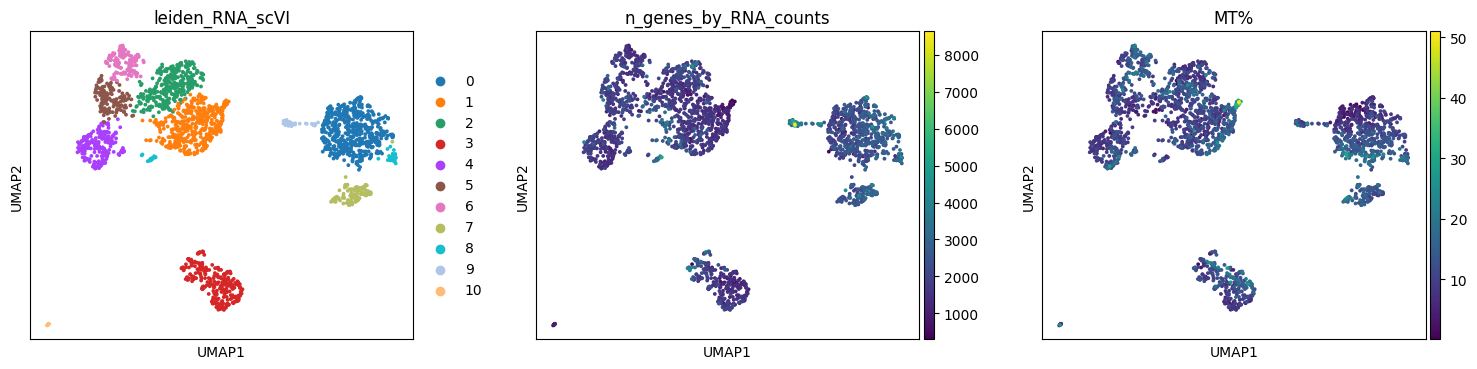

In [39]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_valid_rna, color=['leiden_RNA_scVI',  'n_genes_by_RNA_counts', 'MT%'], wspace=0.2, size=30, ncols=3)

In [35]:
print('Total number of barcodes that passed RNA filtering: ', h5_valid_rna.shape[0])
print('Among those barcodes, number of barcodes that passed ATAC filtering by any of the 3 approaches: ', RNA_valid_bc_set['atac_pass_any'].sum())

Total number of barcodes that passed RNA filtering:  2261
Among those barcodes, number of barcodes that passed ATAC filtering by any of the 3 approaches:  2044


In [54]:
col_list = ['_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'atac_pass_any', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', 'Entropy', 'total_fragments']

for col in col_list:
    h5_valid_rna.obs[col] = h5_valid_rna.obs['atac_barcodes'].map(RNA_valid_bc_set[col])
    
h5_valid_rna.obs['log10_ATAC_readdepth'] = np.log10(h5_valid_rna.obs['total_fragments']+1)

In [55]:
h5_valid_rna.obs.head(2)


,rna_barcodes,atac_barcodes,total_RNA_UMI,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,MT%,_scvi_batch,_scvi_labels,leiden_RNA_scVI,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_pass_CR,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,Entropy,atac_pass_any,total_fragments,log10_ATAC_readdepth
AAACAGCCAGGCTACT-1,AAACAGCCAGGCTACT,ACAGCGGGTTTGTAGC,3931.0,8.276903,1772,519.0,13.202747,0,0,1,both,both,True,True,True,True,0.130478,True,3390,3.530328
AAACATGCAAGGATTA-1,AAACATGCAAGGATTA,CATTTAGGTAACAGCA,3566.0,8.179481,1689,401.0,11.245092,0,0,6,both,both,True,True,True,True,0.197080,True,11169,4.048053


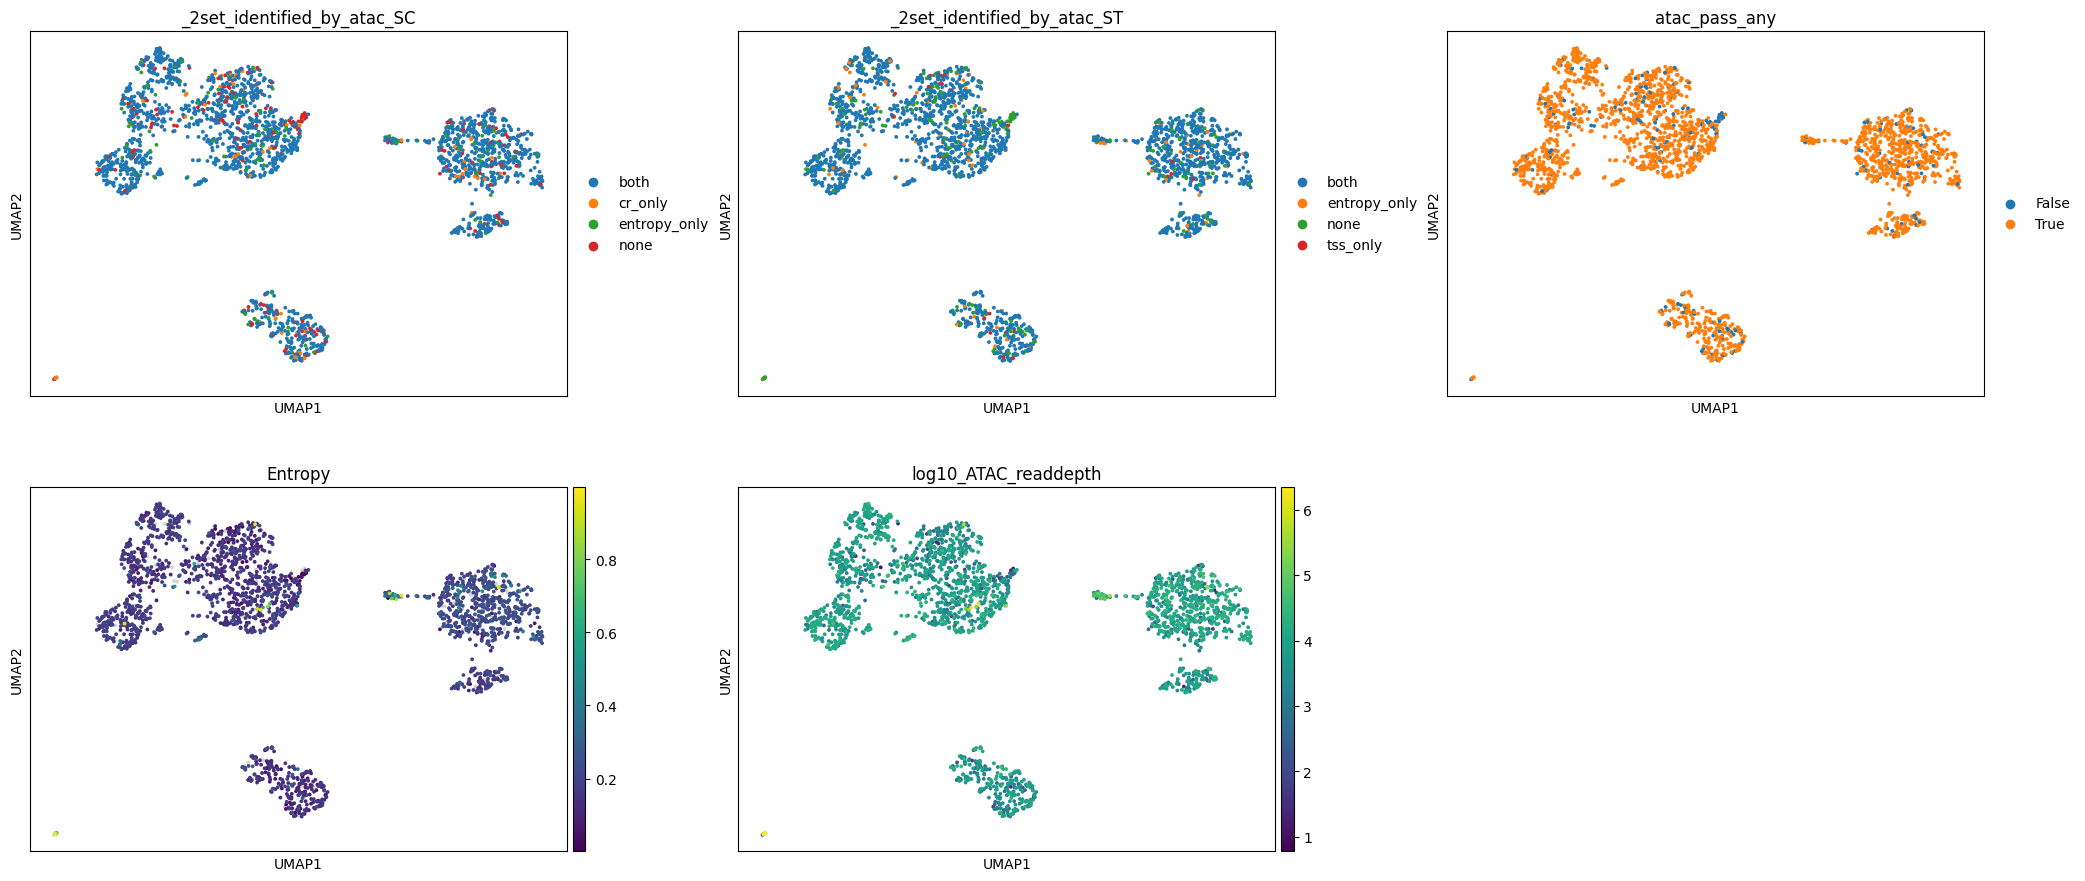

In [56]:

with plt.rc_context({'figure.figsize': (7, 5)}):
    sc.pl.umap(h5_valid_rna, color=['_2set_identified_by_atac_SC',
                                    '_2set_identified_by_atac_ST', 
                              'atac_pass_any']+ 
               ['Entropy', 'log10_ATAC_readdepth'], wspace=0.2, size=30, ncols=3)

<Axes: xlabel='leiden_RNA_scVI', ylabel='count'>

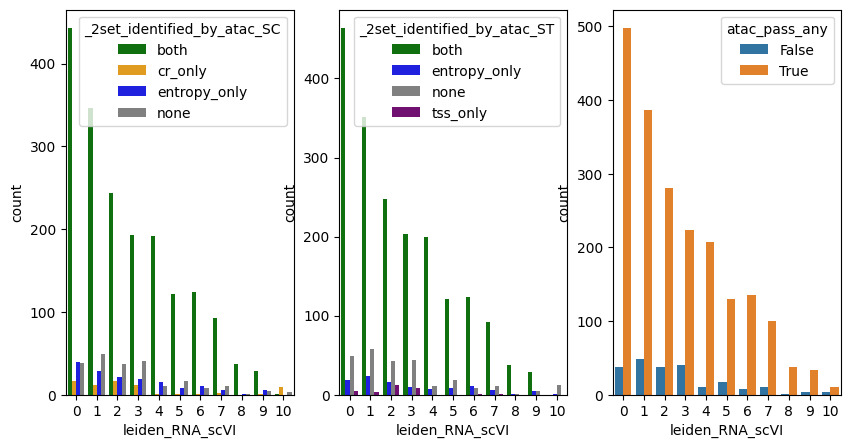

In [48]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))
color_dic = {'both': 'green', 'entropy_only': 'blue', 'cr_only': 'orange',   'tss_only': 'purple', 'none': 'grey', '2 out of 3': 'cyan', 'all': 'red'}
sns.countplot(data=h5_valid_rna.obs, x='leiden_RNA_scVI', hue='_2set_identified_by_atac_SC', palette=color_dic, ax=ax[0])
sns.countplot(data=h5_valid_rna.obs, x='leiden_RNA_scVI', hue='_2set_identified_by_atac_ST', palette=color_dic, ax=ax[1])
sns.countplot(data=h5_valid_rna.obs, x='leiden_RNA_scVI', hue='atac_pass_any', ax=ax[2])


In [57]:
h5_valid_rna.obs.head(2)

,rna_barcodes,atac_barcodes,total_RNA_UMI,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,MT%,_scvi_batch,_scvi_labels,leiden_RNA_scVI,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_pass_CR,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,Entropy,atac_pass_any,total_fragments,log10_ATAC_readdepth
AAACAGCCAGGCTACT-1,AAACAGCCAGGCTACT,ACAGCGGGTTTGTAGC,3931.0,8.276903,1772,519.0,13.202747,0,0,1,both,both,True,True,True,True,0.130478,True,3390,3.530328
AAACATGCAAGGATTA-1,AAACATGCAAGGATTA,CATTTAGGTAACAGCA,3566.0,8.179481,1689,401.0,11.245092,0,0,6,both,both,True,True,True,True,0.197080,True,11169,4.048053


In [ ]:
# Save the barcode info with RNA cluster 
valid_RNA_bc_w_atacinfo_file = os.path.join(RNA_info_subdir, 'Valid_RNA_cell_info.tsv')
h5_valid_rna.obs.to_csv(valid_RNA_bc_w_atacinfo_file, sep='\t')


# Check frag for RNAs cells that failed all atac-cell-calling

In [59]:
RNA_valid_bc_set.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,atac_pass_any,Entropy
atac_bc,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,True,0.218328
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,True,0.074451


In the valid RNA barcodes, 217 failled all ATAC filtering.       
 And among those failed, 145 have invalid entropy value


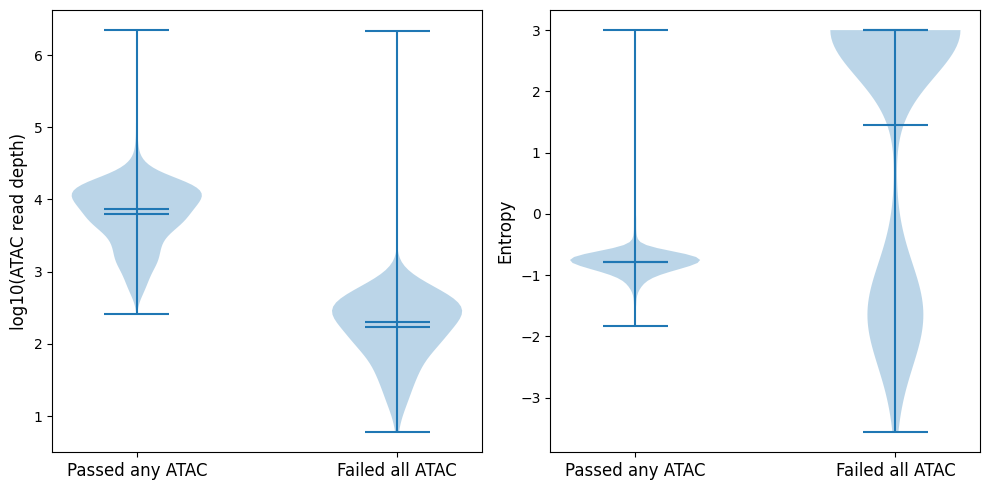

In [79]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
x_positions = [1, 2]
sets = [np.log10(RNA_valid_bc_set.loc[RNA_valid_bc_set['atac_pass_any']]['total_fragments'] + 1), 
        np.log10(RNA_valid_bc_set.loc[~RNA_valid_bc_set['atac_pass_any']]['total_fragments'] + 1)]
ax[0].violinplot(sets, positions=x_positions, showmeans=True, showmedians=True)
ax[0].set_xticks(x_positions)
ax[0].set_xticklabels(['Passed any ATAC', 'Failed all ATAC'], rotation=0, ha='center', fontsize=12)
ax[0].set_ylabel('log10(ATAC read depth)', fontsize=12)

# Fill invalid entropy values with a large number (e.g., 1000) to make them visible in the plot, and log10(1000) = 3
sets = [np.log10(RNA_valid_bc_set.loc[RNA_valid_bc_set['atac_pass_any']]['Entropy'].fillna(1000)) ,
        np.log10(RNA_valid_bc_set.loc[~RNA_valid_bc_set['atac_pass_any']]['Entropy'].fillna(1000))]
ax[1].violinplot(sets, positions=x_positions, showmeans=True, showmedians=True)
ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(['Passed any ATAC', 'Failed all ATAC'], rotation=0, ha='center', fontsize=12)
ax[1].set_ylabel('Entropy', fontsize=12)
plt.tight_layout()

print(f'In the valid RNA barcodes, {RNA_valid_bc_set[~RNA_valid_bc_set["atac_pass_any"]].shape[0]} failled all ATAC filtering. \
      \n And among those failed, {RNA_valid_bc_set.loc[~RNA_valid_bc_set["atac_pass_any"]]["Entropy"].isna().sum()} have invalid entropy value'
      )

In [108]:
failATAC_bc_list_vRNA = RNA_valid_bc_set.loc[~RNA_valid_bc_set['atac_pass_any']].index.tolist()

frag_failATAC_sub_vRNA = frag.loc[frag['atac_bc'].isin(failATAC_bc_list_vRNA)].copy()

In [101]:
invalid_entropy_bc_list_failATAC = RNA_valid_bc_set.loc[RNA_valid_bc_set['Entropy'].isna() & (~RNA_valid_bc_set['atac_pass_any'])].index.tolist()
frag_invalid_entropy_sub_failATAC = frag.loc[frag['atac_bc'].isin(invalid_entropy_bc_list_failATAC)].copy()

In [103]:
valid_entropy_bc_list_failATAC = RNA_valid_bc_set.loc[RNA_valid_bc_set['Entropy'].notna() & (~RNA_valid_bc_set['atac_pass_any'])].index.tolist()
frag_valid_entropy_sub_failATAC = frag.loc[frag['atac_bc'].isin(valid_entropy_bc_list_failATAC)].copy()

In [104]:
frag_failATAC_sub_vRNA.shape[0], frag_invalid_entropy_sub_failATAC.shape[0], frag_valid_entropy_sub_failATAC.shape[0]

(2291772, 27578, 2264194)

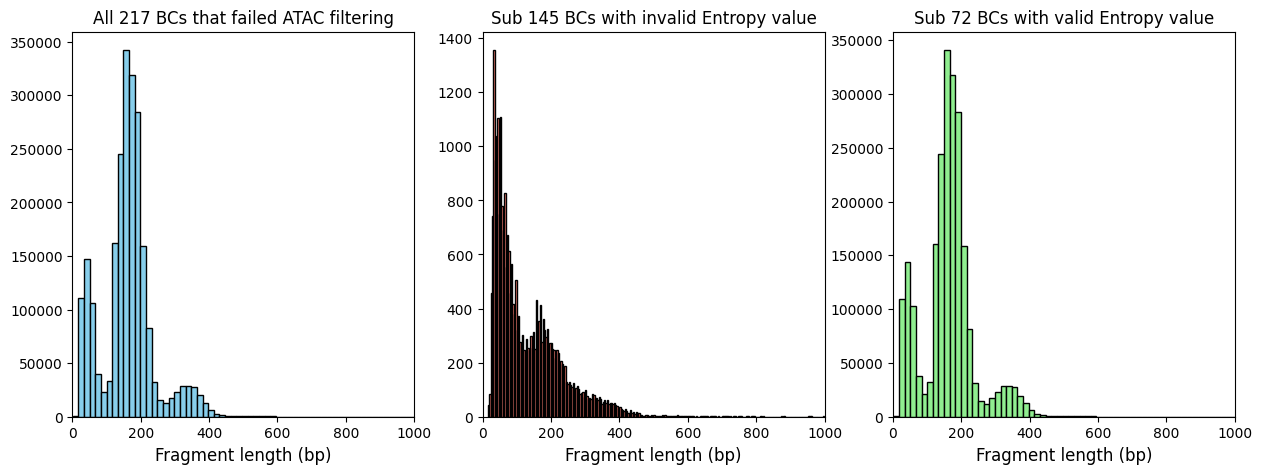

In [109]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
_= ax[0].hist(frag_failATAC_sub_vRNA['frag_length'], bins=300, color='skyblue', edgecolor='black')
ax[0].set_title(f'All {len(failATAC_bc_list_vRNA)} BCs that failed ATAC filtering', fontsize=12)

_= ax[1].hist(frag_invalid_entropy_sub_failATAC['frag_length'], bins=300, color='salmon', edgecolor='black')
ax[1].set_title(f'Sub {len(invalid_entropy_bc_list_failATAC)} BCs with invalid Entropy value', fontsize=12)


_= ax[2].hist(frag_valid_entropy_sub_failATAC['frag_length'], bins=300, color='lightgreen', edgecolor='black')
ax[2].set_title(f'Sub {len(valid_entropy_bc_list_failATAC)} BCs with valid Entropy value', fontsize=12)

for ax_i in ax:
    ax_i.set_xlim(0, 1000)
    ax_i.set_xlabel('Fragment length (bp)', fontsize=12)
